In [2]:
# 1. System, Logging, and Warnings
import os
import logging
import warnings
import joblib  # For saving our models later

# Suppress annoying warnings to keep our notebook clean
warnings.filterwarnings('ignore')

# 2. Data Manipulation & Mathematics
import pandas as pd
import numpy as np

# 3. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Jupyter notebook magic command to show plots directly below cells
%matplotlib inline 

# 4. Machine Learning: Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 5. Handling Data Imbalance (The SMOTE technique we discussed)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Special pipeline that works well with SMOTE


# 6. Machine Learning: Algorithms
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# 7. Machine Learning: Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix, 
                             r2_score, mean_absolute_error)

# 8. Notebook Configurations
%matplotlib inline
sns.set_theme(style="whitegrid") # Makes our charts look professional
warnings.filterwarnings('ignore') # Keeps our notebook clean from unnecessary warnings

print("✅ All packages imported successfully!")

✅ All packages imported successfully!


In [5]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.9 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 3.5 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.8 MB/s  0:00:00


In [4]:
# Create a dedicated directory for our logs to keep things organized
os.makedirs('logs', exist_ok=True)

# Configure the logging system
logging.basicConfig(
    level=logging.INFO, # We want to record INFO, WARNING, and ERROR messages
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('logs/bizness_model_training.log'), # Saves history to a file
        logging.StreamHandler()                                 # Prints to the notebook screen
    ]
)

# Create our specific logger object
logger = logging.getLogger('BizNess_ML')

# Let's test it!
logger.info("Project BizNess Initialized. Imports and configurations loaded successfully.")

2026-02-25 00:47:21,826 - INFO - Project BizNess Initialized. Imports and configurations loaded successfully.


In [5]:
# 1. Define the path to our dataset
dataset_path = 'BizNess_National_Training_Dataset_50k.csv'

# 2. Load the dataset
try:
    df = pd.read_csv(dataset_path)
    # Log the success and the size of the dataset
    logger.info(f"Dataset successfully loaded from {dataset_path}")
    logger.info(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
    print("✅ Dataset loaded successfully!")
except Exception as e:
    logger.error(f"Error loading dataset: {e}")
    print(f"❌ Error: {e}")

# 3. Display the first 5 rows to see what we are working with
df.head()

2026-02-25 00:47:24,120 - INFO - Dataset successfully loaded from BizNess_National_Training_Dataset_50k.csv
2026-02-25 00:47:24,121 - INFO - Dataset Shape: 50000 rows and 37 columns


✅ Dataset loaded successfully!


,Business_ID,Region,Location,Urban_Rural,Sector,Business_Type,SME_Category_Cameroon,Startup_Capital_CFA,Employees,Monthly_Profit_CFA,...,Region_Growth_Rate,Region_Electricity_Index,Region_Infrastructure_Index,Region_Informal_Economy_Index,Region_Security_Index,Sector_Risk_Baseline,Sector_Capital_Intensity,Survival_Probability_Simulated,Risk_Level_Simulated,Survived_3_Years
0,1,West,Dschang,Rural,Education & Training,Education,Micro,12459454,1,282235,...,0.038,0.70,0.72,0.57,0.88,0.42,0.35,0.5578,Medium,0
1,2,Littoral,Manjo,Urban,Agriculture & Agro-processing,Agriculture,Micro,44991979,5,1106873,...,0.045,0.78,0.80,0.52,0.85,0.50,0.55,0.7333,Low,1
2,3,Littoral,Manjo,Rural,Education & Training,Education,Micro,20768165,3,645803,...,0.045,0.78,0.80,0.52,0.85,0.42,0.35,0.5976,Medium,1
3,4,Centre,Yaoundé,Urban,Education & Training,Education,Micro,29241786,4,776253,...,0.040,0.74,0.76,0.55,0.90,0.42,0.35,0.5560,Medium,1
4,5,North,Garoua,Urban,Healthcare,Healthcare,Micro,68451194,5,881644,...,0.028,0.58,0.60,0.62,0.78,0.40,0.55,0.5975,Medium,1


In [6]:
# Display a summary of the dataset
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Check ---")
# Count missing values in each column and only show the ones greater than 0
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Business_ID                     50000 non-null  int64  
 1   Region                          50000 non-null  object 
 2   Location                        50000 non-null  object 
 3   Urban_Rural                     50000 non-null  object 
 4   Sector                          50000 non-null  object 
 5   Business_Type                   50000 non-null  object 
 6   SME_Category_Cameroon           50000 non-null  object 
 7   Startup_Capital_CFA             50000 non-null  int64  
 8   Employees                       50000 non-null  int64  
 9   Monthly_Profit_CFA              50000 non-null  int64  
 10  Market_Competition              50000 non-null  object 
 11  Business_Age_Years              50000 non-null  float64
 12  Year

In [7]:
# 1. Create a copy of the dataframe to keep the original intact
df_cleaned = df.copy()

# 2. Define the columns we want to remove
columns_to_drop = [
    'Business_ID', 
    'Survival_Probability_Simulated', 
    'Risk_Level_Simulated'
]

# Drop them from the dataset
df_cleaned = df_cleaned.drop(columns=columns_to_drop)
logger.info(f"Dropped leaky/identifier columns: {columns_to_drop}")

# 3. Handle missing values in 'Owner_Education'
df_cleaned['Owner_Education'] = df_cleaned['Owner_Education'].fillna('Unknown')
logger.info("Filled missing values in 'Owner_Education' with 'Unknown'")

# 4. Verify the cleaning
print("Remaining columns:", len(df_cleaned.columns))
print("Missing values in Owner_Education:", df_cleaned['Owner_Education'].isnull().sum())

2026-02-25 00:47:28,752 - INFO - Dropped leaky/identifier columns: ['Business_ID', 'Survival_Probability_Simulated', 'Risk_Level_Simulated']
2026-02-25 00:47:28,767 - INFO - Filled missing values in 'Owner_Education' with 'Unknown'


Remaining columns: 34
Missing values in Owner_Education: 0


2026-02-25 00:47:31,276 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-25 00:47:31,386 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


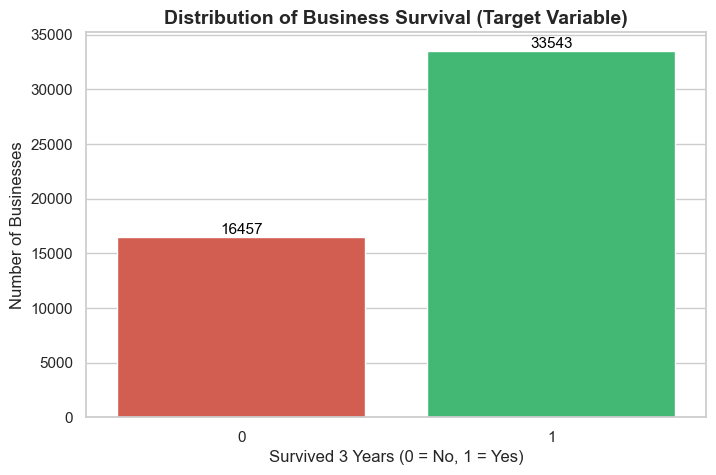

2026-02-25 00:47:32,277 - INFO - Class Distribution - Survived: 67.09%, Failed: 32.91%


In [8]:
# Set up the figure size
plt.figure(figsize=(8, 5))

# Create a count plot for the target variable 'Survived_3_Years'
ax = sns.countplot(data=df_cleaned, x='Survived_3_Years', palette=['#e74c3c', '#2ecc71'])

# Add titles and labels
plt.title('Distribution of Business Survival (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Survived 3 Years (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Businesses', fontsize=12)

# Add the exact count on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black')

plt.show()

# Log the distribution percentages
survival_counts = df_cleaned['Survived_3_Years'].value_counts(normalize=True) * 100
logger.info(f"Class Distribution - Survived: {survival_counts[1]:.2f}%, Failed: {survival_counts[0]:.2f}%")

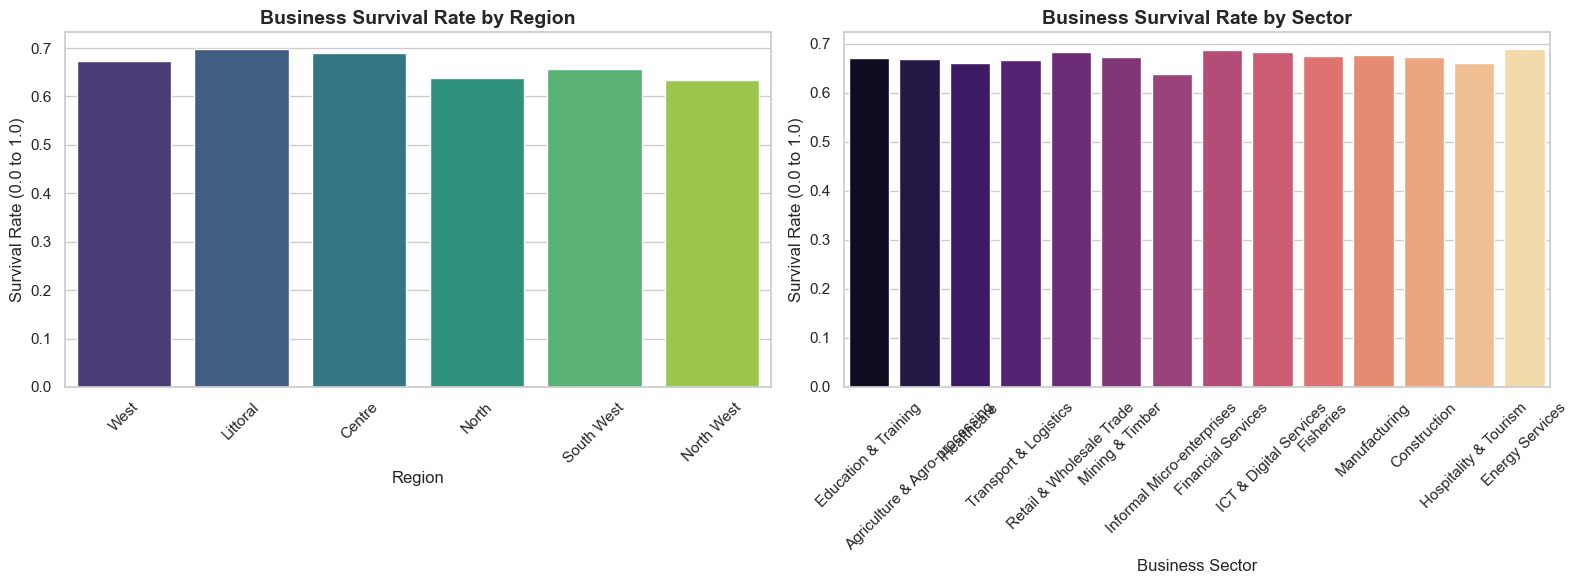

2026-02-25 00:47:35,658 - INFO - Generated EDA plots for Region and Sector vs. Survival.


In [9]:
# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Survival by Region
sns.barplot(data=df_cleaned, x='Region', y='Survived_3_Years', ax=axes[0], palette='viridis', ci=None)
axes[0].set_title('Business Survival Rate by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region', fontsize=12)
axes[0].set_ylabel('Survival Rate (0.0 to 1.0)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap

# Chart 2: Survival by Sector
sns.barplot(data=df_cleaned, x='Sector', y='Survived_3_Years', ax=axes[1], palette='magma', ci=None)
axes[1].set_title('Business Survival Rate by Sector', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Business Sector', fontsize=12)
axes[1].set_ylabel('Survival Rate (0.0 to 1.0)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to make it look neat
plt.tight_layout()
plt.show()

logger.info("Generated EDA plots for Region and Sector vs. Survival.")

In [10]:
# 1. Separate the Target (y) from the Features (X)
X = df_cleaned.drop('Survived_3_Years', axis=1)
y = df_cleaned['Survived_3_Years']

# 2. Split the data into Training (80%) and Testing (20%) sets
# 'stratify=y' ensures the 67/33 ratio of survived/failed is kept the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
logger.info("Data split into 80% Training and 20% Testing sets.")

# 3. Automatically identify numerical and categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4. Create the factory assembly lines (Pipelines) for processing

# For numbers: Fill any accidental missing values with the median, then scale them
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For text: Fill any missing values with 'Unknown', then One-Hot Encode them
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
    # Ignore unknown categories in the future
])

# 5. Combine both assembly lines into one master 'preprocessor'
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

logger.info("Preprocessing Pipeline configured successfully.")

# Print out a summary of what we just did
print(f"✅ Data prepared for the models!")
print(f"-> Training data shape: {X_train.shape} (We will train on 40,000 businesses)")
print(f"-> Testing data shape: {X_test.shape} (We will test on 10,000 businesses)")
print(f"-> Found {len(categorical_cols)} categorical columns and {len(numerical_cols)} numerical columns.")

2026-02-25 00:47:38,485 - INFO - Data split into 80% Training and 20% Testing sets.
2026-02-25 00:47:38,522 - INFO - Preprocessing Pipeline configured successfully.


✅ Data prepared for the models!
-> Training data shape: (40000, 33) (We will train on 40,000 businesses)
-> Testing data shape: (10000, 33) (We will test on 10,000 businesses)
-> Found 14 categorical columns and 19 numerical columns.


2026-02-25 00:47:41,322 - INFO - Training Baseline Model: Logistic Regression with SMOTE...


⏳ Training in progress... Please wait.


2026-02-25 00:47:53,590 - INFO - Baseline Model training completed.
2026-02-25 00:47:53,752 - INFO - Baseline Results - Acc: 0.5533, Precision: 0.5459, Recall: 0.5518, F1: 0.5360


✅ Training complete!
⏳ Evaluating model on test data...

 BASELINE MODEL RESULTS: LOGISTIC REGRESSION
Accuracy:  55.33%
Precision: 54.59% (When it predicts a class, how often is it right?)
Recall:    55.18% (How many of the actual class did it find?)
F1-Score:  53.60% (Balance between Precision and Recall)
--------------------------------------------------
DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Failed (0)       0.38      0.55      0.45      3291
Survived (1)       0.71      0.56      0.63      6709

    accuracy                           0.55     10000
   macro avg       0.55      0.55      0.54     10000
weighted avg       0.60      0.55      0.57     10000



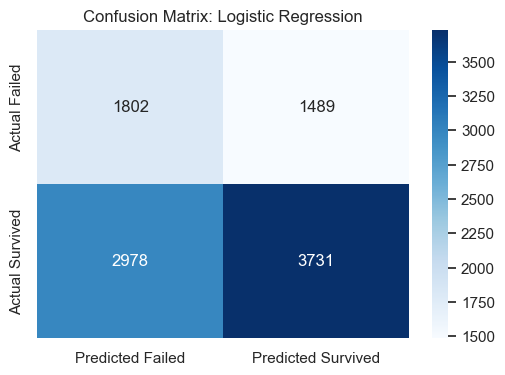

In [11]:
# 1. Build the complete Machine Learning Pipeline
# We MUST use the ImbPipeline (from imblearn) because standard sklearn pipelines don't support SMOTE
baseline_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),           # Step 1: Clean and scale the data
    ('smote', SMOTE(random_state=42)),        # Step 2: Balance the dataset (fix the 67/33 ratio)
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)) # Step 3: Train the model
])

logger.info("Training Baseline Model: Logistic Regression with SMOTE...")
print("⏳ Training in progress... Please wait.")

# 2. Train (fit) the model on our 40,000 training records
baseline_pipeline.fit(X_train, y_train)
logger.info("Baseline Model training completed.")
print("✅ Training complete!")

# 3. Test the model on our 10,000 unseen testing records
print("⏳ Evaluating model on test data...")
y_pred_baseline = baseline_pipeline.predict(X_test)

# 4. Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
# We focus on the 'macro' average to ensure it performs well on both Survived and Failed classes
precision = precision_score(y_test, y_pred_baseline, average='macro')
recall = recall_score(y_test, y_pred_baseline, average='macro')
f1 = f1_score(y_test, y_pred_baseline, average='macro')

# Log the results
logger.info(f"Baseline Results - Acc: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

# 5. Display the beautiful Classification Report
print("\n" + "="*50)
print(" BASELINE MODEL RESULTS: LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}% (When it predicts a class, how often is it right?)")
print(f"Recall:    {recall * 100:.2f}% (How many of the actual class did it find?)")
print(f"F1-Score:  {f1 * 100:.2f}% (Balance between Precision and Recall)")
print("-" * 50)
print("DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_baseline, target_names=['Failed (0)', 'Survived (1)']))

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Failed', 'Predicted Survived'], yticklabels=['Actual Failed', 'Actual Survived'])
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

2026-02-25 00:47:58,070 - INFO - Training Advanced Model: Random Forest Classifier with SMOTE...


⏳ Training Random Forest (building 100 decision trees)... This might take a minute or two!


2026-02-25 00:48:14,041 - INFO - Random Forest training completed.


 Training complete!
⏳ Evaluating Random Forest on test data...


2026-02-25 00:48:14,435 - INFO - Random Forest Results - Acc: 0.6638, Precision: 0.5477, Recall: 0.5092, F1: 0.4467



 ADVANCED MODEL RESULTS: RANDOM FOREST
Accuracy:  66.38%
Precision: 54.77%
Recall:    50.92%
F1-Score:  44.67%
--------------------------------------------------
DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Failed (0)       0.42      0.06      0.10      3291
Survived (1)       0.68      0.96      0.79      6709

    accuracy                           0.66     10000
   macro avg       0.55      0.51      0.45     10000
weighted avg       0.59      0.66      0.57     10000



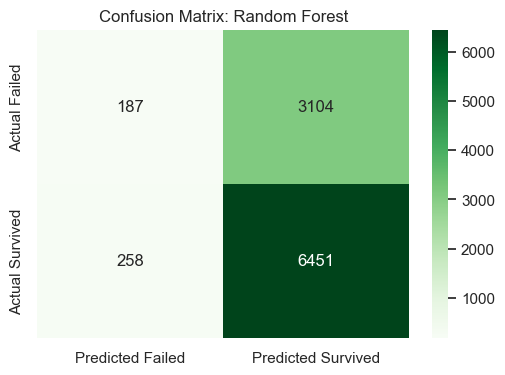

In [12]:
logger.info("Training Advanced Model: Random Forest Classifier with SMOTE...")
print("⏳ Training Random Forest (building 100 decision trees)... This might take a minute or two!")

# 1. Build the Random Forest Pipeline
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    # n_jobs=-1 tells the computer to use all its processors to train faster
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)) 
])

# 2. Train the model
rf_pipeline.fit(X_train, y_train)
logger.info("Random Forest training completed.")
print(" Training complete!")

# 3. Test the model
print("⏳ Evaluating Random Forest on test data...")
y_pred_rf = rf_pipeline.predict(X_test)

# 4. Calculate Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='macro')
recall_rf = recall_score(y_test, y_pred_rf, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

logger.info(f"Random Forest Results - Acc: {accuracy_rf:.4f}, Precision: {precision_rf:.4f}, Recall: {recall_rf:.4f}, F1: {f1_rf:.4f}")

# 5. Display the Results
print("\n" + "="*50)
print(" ADVANCED MODEL RESULTS: RANDOM FOREST")
print("="*50)
print(f"Accuracy:  {accuracy_rf * 100:.2f}%")
print(f"Precision: {precision_rf * 100:.2f}%")
print(f"Recall:    {recall_rf * 100:.2f}%")
print(f"F1-Score:  {f1_rf * 100:.2f}%")
print("-" * 50)
print("DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['Failed (0)', 'Survived (1)']))

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Predicted Failed', 'Predicted Survived'], yticklabels=['Actual Failed', 'Actual Survived'])
plt.title('Confusion Matrix: Random Forest')
plt.show()

2026-02-25 00:48:18,740 - INFO - Training Advanced Model: XGBoost Classifier with SMOTE...


⏳ Training XGBoost... This algorithm learns from its mistakes iteratively!


2026-02-25 00:48:26,076 - INFO - XGBoost training completed.
2026-02-25 00:48:26,268 - INFO - XGBoost Results - Acc: 0.6667, Precision: 0.5193, Recall: 0.5014, F1: 0.4161


✅ Training complete!
⏳ Evaluating XGBoost on test data...

🚀 ULTIMATE MODEL RESULTS: XGBOOST
Accuracy:  66.67%
Precision: 51.93%
Recall:    50.14%
F1-Score:  41.61%
--------------------------------------------------
DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Failed (0)       0.37      0.02      0.03      3291
Survived (1)       0.67      0.99      0.80      6709

    accuracy                           0.67     10000
   macro avg       0.52      0.50      0.42     10000
weighted avg       0.57      0.67      0.55     10000



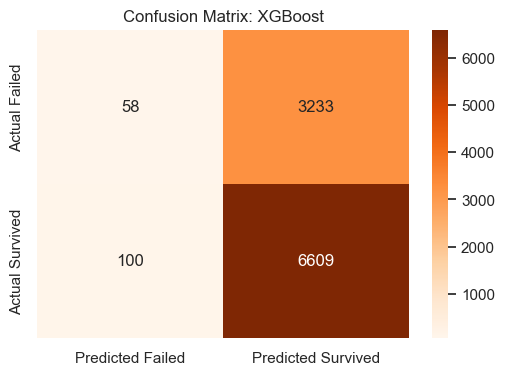

In [13]:
logger.info("Training Advanced Model: XGBoost Classifier with SMOTE...")
print("⏳ Training XGBoost... This algorithm learns from its mistakes iteratively!")

# 1. Build the XGBoost Pipeline
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    # We add XGBClassifier. eval_metric='logloss' keeps the console quiet from warnings
    ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')) 
])

# 2. Train the model
xgb_pipeline.fit(X_train, y_train)
logger.info("XGBoost training completed.")
print("✅ Training complete!")

# 3. Test the model
print("⏳ Evaluating XGBoost on test data...")
y_pred_xgb = xgb_pipeline.predict(X_test)

# 4. Calculate Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='macro')
recall_xgb = recall_score(y_test, y_pred_xgb, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

logger.info(f"XGBoost Results - Acc: {accuracy_xgb:.4f}, Precision: {precision_xgb:.4f}, Recall: {recall_xgb:.4f}, F1: {f1_xgb:.4f}")

# 5. Display the Results
print("\n" + "="*50)
print("🚀 ULTIMATE MODEL RESULTS: XGBOOST")
print("="*50)
print(f"Accuracy:  {accuracy_xgb * 100:.2f}%")
print(f"Precision: {precision_xgb * 100:.2f}%")
print(f"Recall:    {recall_xgb * 100:.2f}%")
print(f"F1-Score:  {f1_xgb * 100:.2f}%")
print("-" * 50)
print("DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_xgb, target_names=['Failed (0)', 'Survived (1)']))

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Predicted Failed', 'Predicted Survived'], yticklabels=['Actual Failed', 'Actual Survived'])
plt.title('Confusion Matrix: XGBoost')
plt.show()

2026-02-25 00:48:39,550 - INFO - Training Cost-Sensitive Model: Random Forest with Balanced Weights...


⏳ Training Model with strict mathematical penalties for missing failures...


2026-02-25 00:48:47,820 - INFO - Cost-Sensitive Random Forest training completed.


✅ Training complete!
⏳ Evaluating the new model on test data...

⚖️ COST-SENSITIVE MODEL RESULTS: RANDOM FOREST
DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Failed (0)       0.42      0.02      0.04      3291
Survived (1)       0.67      0.98      0.80      6709

    accuracy                           0.67     10000
   macro avg       0.55      0.50      0.42     10000
weighted avg       0.59      0.67      0.55     10000



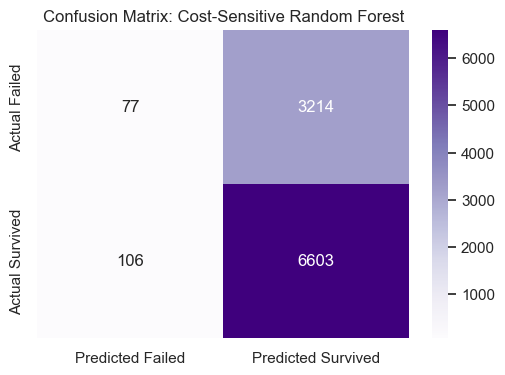

In [14]:
# We use the standard sklearn Pipeline now since we are removing SMOTE
from sklearn.pipeline import Pipeline as SklearnPipeline

logger.info("Training Cost-Sensitive Model: Random Forest with Balanced Weights...")
print("⏳ Training Model with strict mathematical penalties for missing failures...")

# 1. Build the Cost-Sensitive Pipeline (NO SMOTE)
cost_sensitive_rf = SklearnPipeline(steps=[
    ('preprocessor', preprocessor),
    # The magic parameter: class_weight='balanced'
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', # This forces the model to pay attention to failed businesses!
        random_state=42, 
        n_jobs=-1
    )) 
])

# 2. Train the model
cost_sensitive_rf.fit(X_train, y_train)
logger.info("Cost-Sensitive Random Forest training completed.")
print("✅ Training complete!")

# 3. Test the model
print("⏳ Evaluating the new model on test data...")
y_pred_cs = cost_sensitive_rf.predict(X_test)

# 4. Display the Results
print("\n" + "="*50)
print("⚖️ COST-SENSITIVE MODEL RESULTS: RANDOM FOREST")
print("="*50)
print("DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_cs, target_names=['Failed (0)', 'Survived (1)']))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm_cs = confusion_matrix(y_test, y_pred_cs)
sns.heatmap(cm_cs, annot=True, fmt='d', cmap='Purples', xticklabels=['Predicted Failed', 'Predicted Survived'], yticklabels=['Actual Failed', 'Actual Survived'])
plt.title('Confusion Matrix: Cost-Sensitive Random Forest')
plt.show()


2026-02-25 00:49:46,693 - INFO - Training LightGBM and CatBoost with Balanced Weights...


⏳ Training LightGBM...
[LightGBM] [Info] Number of positive: 26834, number of negative: 13166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

⚡ LIGHTGBM RESULTS
              precision    recall  f1-score   support

  Failed (0)       0.37      0.50      0.43      3291
Survived (1)       0.70      0.58      0.64      6709

    accuracy                           0.55     10000
   macro avg       0.54      0.54      0.53     10000
weighted avg       0.59      0.55      0.57     10000


⏳ Training CatBoost...

🐱 CATBOOST RESULTS
              precision    recall  f1-score   support

  Failed (0)       0.38      0.46   

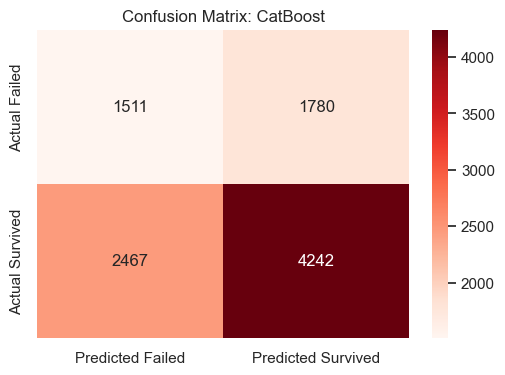

In [15]:
logger.info("Training LightGBM and CatBoost with Balanced Weights...")

# ==========================================
# 1. LIGHTGBM MODEL
# ==========================================
print("⏳ Training LightGBM...")
lgbm_pipeline = SklearnPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

print("\n" + "="*50)
print("⚡ LIGHTGBM RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_lgbm, target_names=['Failed (0)', 'Survived (1)']))


# ==========================================
# 2. CATBOOST MODEL
# ==========================================
print("\n⏳ Training CatBoost...")
cat_pipeline = SklearnPipeline(steps=[
    ('preprocessor', preprocessor),
    # CatBoost uses 'auto_class_weights' instead of 'class_weight'
    # verbose=0 keeps the output clean so it doesn't print 1000 lines of training logs
    ('classifier', CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0))
])

cat_pipeline.fit(X_train, y_train)
y_pred_cat = cat_pipeline.predict(X_test)

print("\n" + "="*50)
print("🐱 CATBOOST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_cat, target_names=['Failed (0)', 'Survived (1)']))

# Let's plot the CatBoost confusion matrix since it usually performs best
plt.figure(figsize=(6, 4))
cm_cat = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Reds', xticklabels=['Predicted Failed', 'Predicted Survived'], yticklabels=['Actual Failed', 'Actual Survived'])
plt.title('Confusion Matrix: CatBoost')
plt.show()

In [16]:
logger.info("Applying Custom Decision Thresholds to CatBoost...")

# 1. Ask the CatBoost model for the EXACT probabilities, not just Yes/No
# This returns an array of probabilities [Prob_Failed, Prob_Survived]
probabilities = cat_pipeline.predict_proba(X_test)

# We only care about the probability of SURVIVING (which is the second column, index 1)
prob_survival = probabilities[:, 1]

# 2. Let's test different strictness levels!
# Instead of 50%, what if we require a 60% or 70% confidence for a business to be called "Safe"?
thresholds = [0.4, 0.5, 0.6, 0.7]

print("🔍 TESTING DIFFERENT RISK THRESHOLDS 🔍\n")

for thresh in thresholds:
    # If probability is greater than our threshold, it's a 1 (Survived), else 0 (Failed)
    custom_predictions = (prob_survival >= thresh).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(y_test, custom_predictions)
    rec_failed = recall_score(y_test, custom_predictions, pos_label=0) # Recall for Failed
    rec_survived = recall_score(y_test, custom_predictions, pos_label=1) # Recall for Survived
    
    print(f"--- Threshold: {thresh * 100:.0f}% ---")
    print(f"If the model is less than {thresh * 100:.0f}% confident, we warn the user it might FAIL.")
    print(f"Overall Accuracy:       {acc * 100:.2f}%")
    print(f"Caught Failing SMEs:    {rec_failed * 100:.2f}% (Recall Class 0)")
    print(f"Caught Surviving SMEs:  {rec_survived * 100:.2f}% (Recall Class 1)\n")

2026-02-25 00:50:38,919 - INFO - Applying Custom Decision Thresholds to CatBoost...


🔍 TESTING DIFFERENT RISK THRESHOLDS 🔍

--- Threshold: 40% ---
If the model is less than 40% confident, we warn the user it might FAIL.
Overall Accuracy:       65.12%
Caught Failing SMEs:    10.45% (Recall Class 0)
Caught Surviving SMEs:  91.94% (Recall Class 1)

--- Threshold: 50% ---
If the model is less than 50% confident, we warn the user it might FAIL.
Overall Accuracy:       57.53%
Caught Failing SMEs:    45.91% (Recall Class 0)
Caught Surviving SMEs:  63.23% (Recall Class 1)

--- Threshold: 60% ---
If the model is less than 60% confident, we warn the user it might FAIL.
Overall Accuracy:       43.26%
Caught Failing SMEs:    82.65% (Recall Class 0)
Caught Surviving SMEs:  23.94% (Recall Class 1)

--- Threshold: 70% ---
If the model is less than 70% confident, we warn the user it might FAIL.
Overall Accuracy:       34.83%
Caught Failing SMEs:    96.81% (Recall Class 0)
Caught Surviving SMEs:  4.43% (Recall Class 1)



2026-02-25 00:51:01,192 - INFO - Extracting Feature Importance from CatBoost...


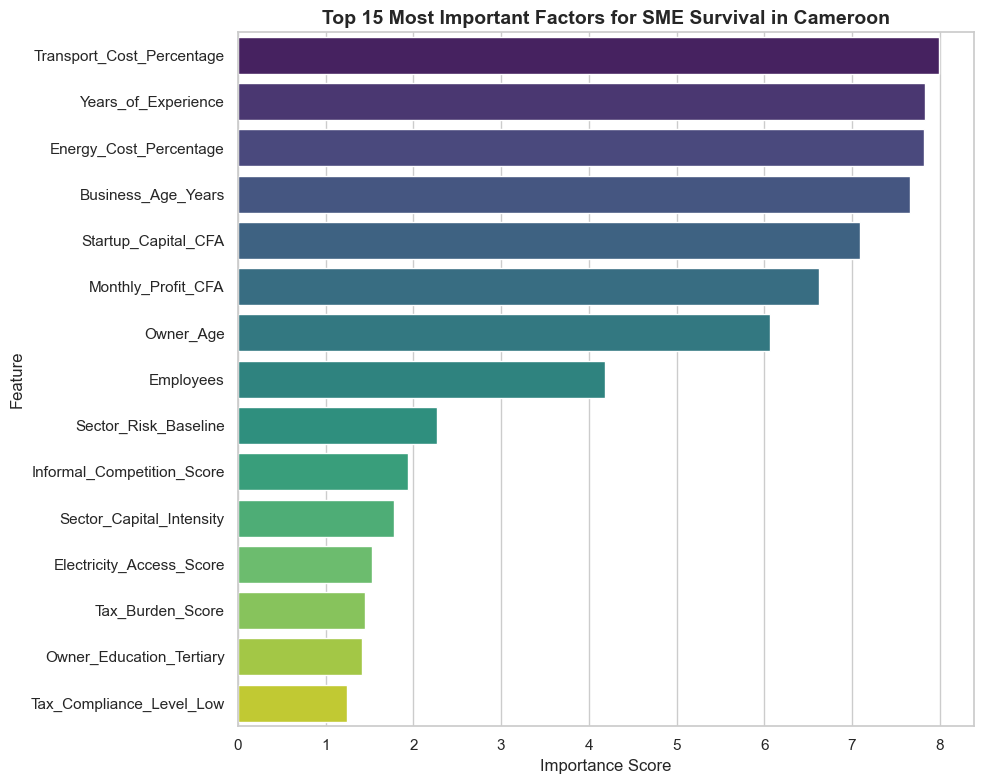

2026-02-25 00:51:02,792 - INFO - Feature importance chart generated successfully.


In [17]:
logger.info("Extracting Feature Importance from CatBoost...")

# 1. Get the trained CatBoost model directly from our pipeline
cat_model = cat_pipeline.named_steps['classifier']

# 2. Get the feature names from the preprocessor
# This gets the names of all the numerical columns and the One-Hot Encoded text columns
feature_names = cat_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Get the importance scores from the AI
importances = cat_model.get_feature_importance()

# 4. Create a Pandas DataFrame to organize the scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Clean up the feature names (remove 'num__' and 'cat__' prefixes added by the pipeline)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# Sort them from highest importance to lowest
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot the Top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Factors for SME Survival in Cameroon', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

logger.info("Feature importance chart generated successfully.")

In [18]:
logger.info("Starting Feature Engineering...")

# 1. Create the new engineered features on our cleaned dataset
df_engineered = df_cleaned.copy()

df_engineered['Total_Overhead_Burden'] = df_engineered['Transport_Cost_Percentage'] + df_engineered['Energy_Cost_Percentage']
df_engineered['Capital_Per_Employee'] = df_engineered['Startup_Capital_CFA'] / df_engineered['Employees']
df_engineered['Risk_to_Experience_Ratio'] = df_engineered['Sector_Risk_Baseline'] / (df_engineered['Years_of_Experience'] + 1)

logger.info("Engineered 3 new features: Total_Overhead_Burden, Capital_Per_Employee, Risk_to_Experience_Ratio.")

# 2. Re-split the data with the new features
X_eng = df_engineered.drop('Survived_3_Years', axis=1)
y_eng = df_engineered['Survived_3_Years']

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

# 3. Update our preprocessor to recognize the new numerical columns
numerical_cols_eng = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_eng = X_train_eng.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_cols_eng),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols_eng)
    ])

# 4. Re-train CatBoost with the engineered data
print("⏳ Training CatBoost with engineered features...")
cat_pipeline_eng = SklearnPipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0))
])

cat_pipeline_eng.fit(X_train_eng, y_train_eng)

# 5. Test the newly trained model
y_pred_cat_eng = cat_pipeline_eng.predict(X_test_eng)

print("\n" + "="*50)
print("🛠️ FEATURE ENGINEERED MODEL RESULTS: CATBOOST")
print("="*50)
print(classification_report(y_test_eng, y_pred_cat_eng, target_names=['Failed (0)', 'Survived (1)']))

# Let's check the new feature importances!
cat_model_eng = cat_pipeline_eng.named_steps['classifier']
feature_names_eng = cat_pipeline_eng.named_steps['preprocessor'].get_feature_names_out()
importances_eng = cat_model_eng.get_feature_importance()

feature_importance_df_eng = pd.DataFrame({'Feature': feature_names_eng, 'Importance': importances_eng})
feature_importance_df_eng['Feature'] = feature_importance_df_eng['Feature'].str.replace('num__', '').str.replace('cat__', '')
feature_importance_df_eng = feature_importance_df_eng.sort_values(by='Importance', ascending=False)

print("\n🌟 Top 5 Most Important Features Now:")
print(feature_importance_df_eng.head(5).to_string(index=False))

2026-02-25 00:51:06,876 - INFO - Starting Feature Engineering...
2026-02-25 00:51:06,906 - INFO - Engineered 3 new features: Total_Overhead_Burden, Capital_Per_Employee, Risk_to_Experience_Ratio.


⏳ Training CatBoost with engineered features...

🛠️ FEATURE ENGINEERED MODEL RESULTS: CATBOOST
              precision    recall  f1-score   support

  Failed (0)       0.38      0.46      0.41      3291
Survived (1)       0.70      0.62      0.66      6709

    accuracy                           0.57     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.59      0.57      0.58     10000


🌟 Top 5 Most Important Features Now:
                  Feature  Importance
       Business_Age_Years    6.730829
   Energy_Cost_Percentage    6.416383
Transport_Cost_Percentage    6.115052
       Monthly_Profit_CFA    6.047134
     Capital_Per_Employee    5.632024


In [19]:
import joblib
import os

logger.info("Initiating Model Save Process...")

# 1. Create a dedicated folder for our production models
os.makedirs('backend/models', exist_ok=True)

# 2. Define the file paths
model_path = 'backend/models/sme_survival_catboost_v1.pkl'
features_path = 'backend/models/training_features_v1.pkl'

# 3. Save the entire pipeline (Preprocessor + Engineered CatBoost Model)
joblib.dump(cat_pipeline_eng, model_path)

# 4. Save the exact list of columns the model expects (crucial for FastAPI later!)
joblib.dump(X_train_eng.columns.tolist(), features_path)

logger.info(f"✅ Model successfully saved to {model_path}")
logger.info(f"✅ Feature list successfully saved to {features_path}")

print("🎉 SUCCESS! The Survival Classification Model is officially complete and saved for production.")

2026-02-25 00:51:39,698 - INFO - Initiating Model Save Process...
--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\clovi\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\clovi\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 33: character maps to <undefined>
Call stack:
  File "C:\Users\clovi\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\clovi\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\clovi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\clovi\ana

🎉 SUCCESS! The Survival Classification Model is officially complete and saved for production.


2026-02-25 00:52:04,739 - INFO - Initializing Profit Forecasting (Regression) Model...


⏳ Training XGBoost Regressor for Profit Forecasting...


2026-02-25 00:52:08,171 - INFO - XGBoost Regression training completed.


✅ Training complete!
⏳ Evaluating model on test data...


2026-02-25 00:52:08,494 - INFO - Regression Results - MAE: 323955.09 CFA, R2: 0.4920



📈 PROFIT FORECASTING RESULTS: XGBOOST REGRESSOR
R-Squared ($R^2$): 49.20% (How much of the profit variance our model explains)
Mean Absolute Error (MAE): 323,955.09 CFA (How far off our predictions are on average)
--------------------------------------------------


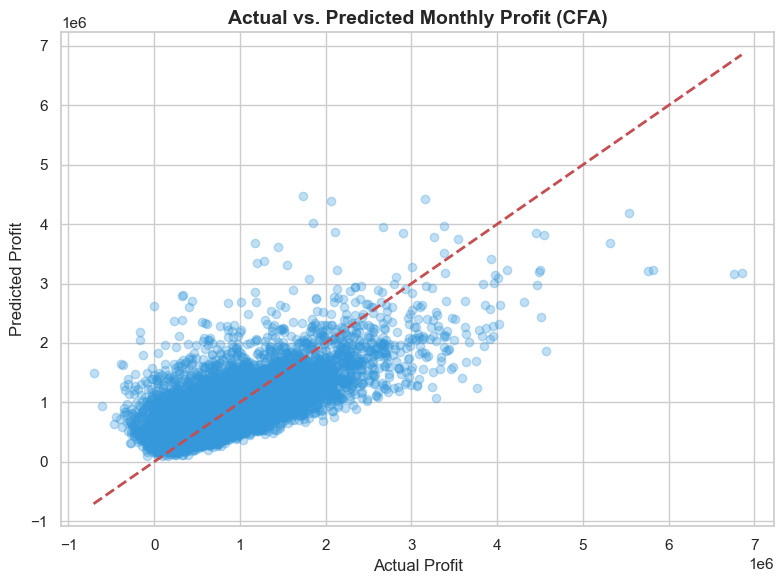

In [20]:
logger.info("Initializing Profit Forecasting (Regression) Model...")

# 1. Define our new Target (y) and Features (X)
# We drop the profit column (because it's the target) and the survival column
X_reg = df_engineered.drop(columns=['Monthly_Profit_CFA', 'Survived_3_Years'])
y_reg = df_engineered['Monthly_Profit_CFA']

# 2. Split the data into Training (80%) and Testing (20%)
# Notice we don't use 'stratify' here because we are predicting continuous numbers, not categories
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Setup the Preprocessor for the Regression features
num_cols_reg = X_train_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_reg = X_train_reg.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols_reg),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols_reg)
    ])

# 4. Build the XGBoost Regression Pipeline
print("⏳ Training XGBoost Regressor for Profit Forecasting...")
xgb_reg_pipeline = SklearnPipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', XGBRegressor(n_estimators=150, learning_rate=0.1, random_state=42, n_jobs=-1))
])

# 5. Train the model
xgb_reg_pipeline.fit(X_train_reg, y_train_reg)
logger.info("XGBoost Regression training completed.")
print("✅ Training complete!")

# 6. Test the model and calculate Regression Metrics
print("⏳ Evaluating model on test data...")
y_pred_reg = xgb_reg_pipeline.predict(X_test_reg)

# Calculate MAE (Mean Absolute Error) and R-Squared (R2)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

logger.info(f"Regression Results - MAE: {mae:.2f} CFA, R2: {r2:.4f}")

# 7. Display the Results
print("\n" + "="*50)
print("📈 PROFIT FORECASTING RESULTS: XGBOOST REGRESSOR")
print("="*50)
print(f"R-Squared ($R^2$): {r2 * 100:.2f}% (How much of the profit variance our model explains)")
print(f"Mean Absolute Error (MAE): {mae:,.2f} CFA (How far off our predictions are on average)")
print("-" * 50)

# 8. Visualize Actual vs. Predicted Profit
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, color='#3498db')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Monthly Profit (CFA)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Profit', fontsize=12)
plt.ylabel('Predicted Profit', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
logger.info("Saving the Profit Forecasting Model...")

# Define the file path for the regression model
reg_model_path = 'backend/models/sme_profit_xgboost_v1.pkl'

# Save the trained XGBoost Regression pipeline
joblib.dump(xgb_reg_pipeline, reg_model_path)

logger.info(f"✅ Profit model successfully saved to {reg_model_path}")
print("🎉 SUCCESS! The Profit Forecasting Model is saved for production.")

2026-02-25 00:52:14,804 - INFO - Saving the Profit Forecasting Model...
--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\clovi\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\clovi\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 33: character maps to <undefined>
Call stack:
  File "C:\Users\clovi\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\clovi\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\clovi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\clo

🎉 SUCCESS! The Profit Forecasting Model is saved for production.
